# Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import osmnx as ox
import geopandas as gpd
from matplotlib_scalebar.scalebar import ScaleBar

# Data

In [2]:
data_rumah = pd.read_csv("/mnt/extended-home/ismaprasetiyadi/skripsi/data/clean_final_data_mitula_lamudi.csv")
data_rumah.head(3)

,Harga_Asli,kecamatan,bedroom,bathrooms,jumlah_guest_toilet,list_facilities,list_buildings,lantai,area_digunakan,luas_tanah,latitude,longitude
0,385000000,Wonoayu,2,1,1,"Internet, Air, Tanpa perabotan, Halaman, Listrik","Keamanan, Taman, Keamanan 24 jam, Area anak-an...",1,34,10,-7.437160,112.622220
1,540000000,Sedati,2,1,1,"Garasi, AC, Kabel video, Air, Tanpa perabotan,...","Keamanan, Gym, Taman, Rumah jaga, Keamanan 24 ...",1,32,32,-7.395451,112.769745
2,1960000000,Candi,4,3,3,"Garasi, AC, Dapur lengkap, Tangki air, Listrik...","Area anak-anak, Rumah jaga, Taman, Keamanan 24...",3,72,32,-7.458483,112.700560


In [3]:
data_fasum = pd.read_csv("/mnt/extended-home/ismaprasetiyadi/skripsi/data/new_fasilitas_sidoarjo_complete_bandara.csv")
data_fasum.head(3)

,name,amenity,latitude,longitude,category_group,brand,tourism,highway,railway,public_transport,shop,leisure,sport,aeroway,barrier,kategori_spesifik
0,SD Negeri Sidodadi 1,school,-7.382526,112.646959,sekolah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SD
1,SDN Kragan,school,-7.409218,112.744903,sekolah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SD
2,SDN Sumorame 1,school,-7.492930,112.705003,sekolah,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SD


# Eksplorasi Data

## Peta OSMNX

In [4]:
GRAPH_PATH = "/mnt/extended-home/ismaprasetiyadi/skripsi/data/sidoarjo_drive.graphml"
NETWORK_TYPE = "drive"

kecamatan = gpd.read_file(
    "/mnt/extended-home/ismaprasetiyadi/skripsi/data/35.15_kecamatan.geojson"
)

north = data_rumah['latitude'].max()
south = data_rumah['latitude'].min()
east = data_rumah['longitude'].max()
west = data_rumah['longitude'].min()

if os.path.exists(GRAPH_PATH):
    print("Load peta dari file lokal...")
    G = ox.load_graphml(GRAPH_PATH)
else:
    print("Download peta dari OpenStreetMap...")
    G = ox.graph_from_bbox(
        bbox=(north, south, east, west),
        network_type=NETWORK_TYPE
    )
    ox.save_graphml(G, GRAPH_PATH)
    print(f"Peta disimpan ke: {GRAPH_PATH}")

Load peta dari file lokal...


### OSMNX Rumah

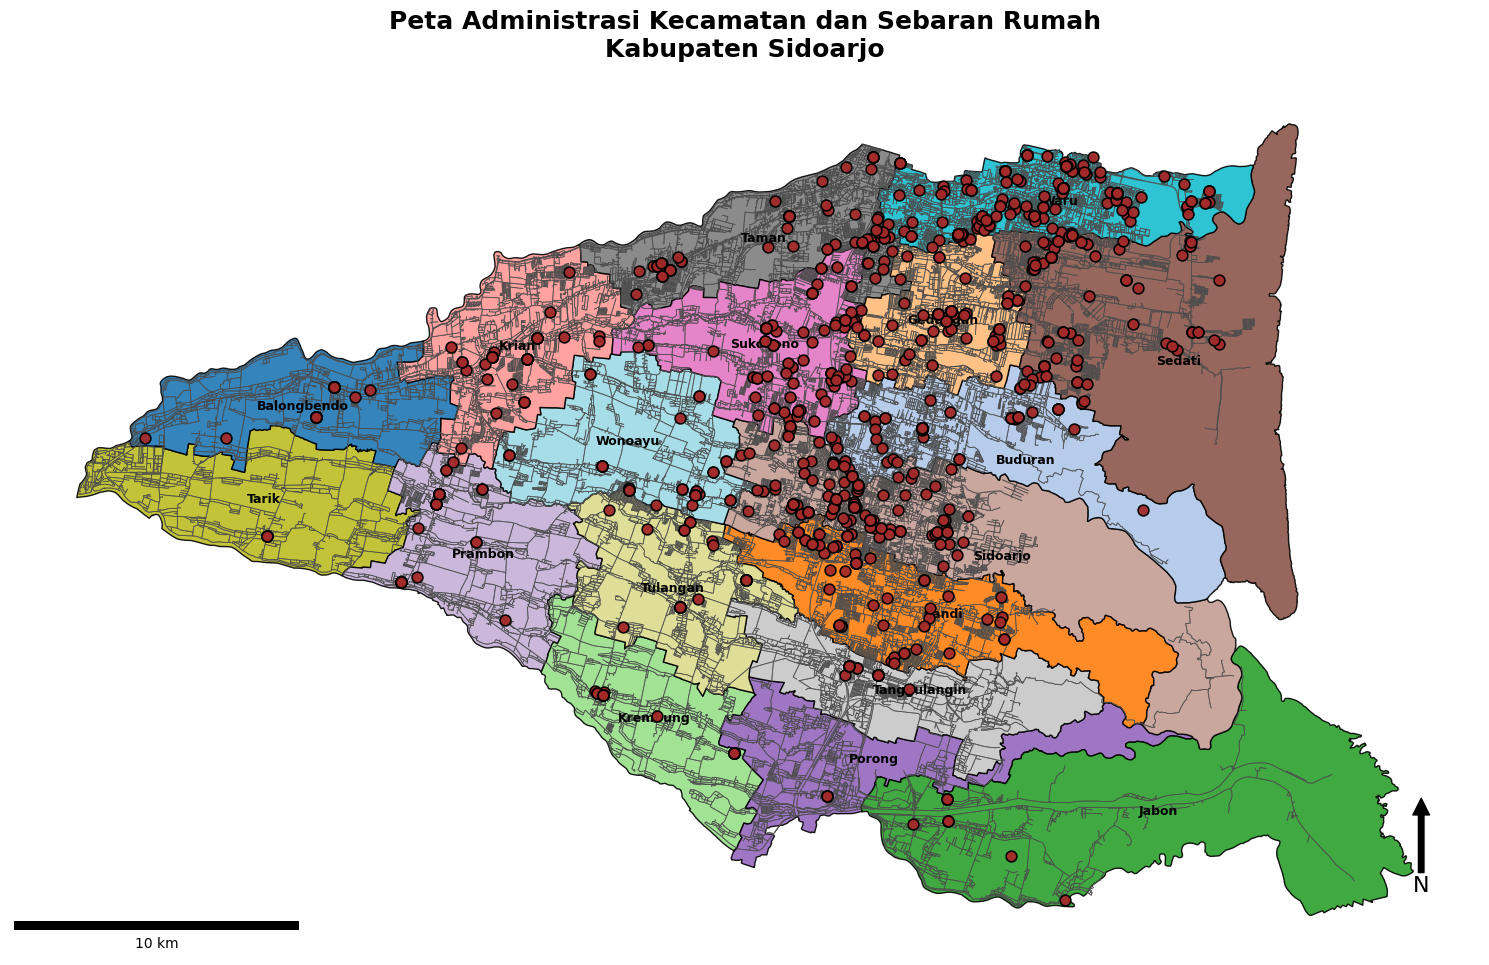

In [8]:
# Pastikan CRS
if kecamatan.crs is None:
    kecamatan = kecamatan.set_crs(epsg=4326)

# Proyeksi ke meter
kecamatan = kecamatan.to_crs(epsg=3857)

# GRAPH JALAN (OSMNX)
nodes, edges = ox.graph_to_gdfs(G)
edges = edges.to_crs(epsg=3857)

# TITIK RUMAH
rumah = gpd.GeoDataFrame(
    data_rumah,
    geometry=gpd.points_from_xy(
        data_rumah.longitude,
        data_rumah.latitude
    ),
    crs="EPSG:4326"
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(15, 12))
kecamatan.plot(
    ax=ax,
    column="nm_kecamatan",   
    cmap="tab20",
    edgecolor="black",
    linewidth=1,
    alpha=0.9,
    zorder=0
)

# JALAN
edges.plot(
    ax=ax,
    linewidth=0.6,
    color="#4d4d4d",
    alpha=0.8,
    zorder=1
)

# TITIK RUMAH
rumah.plot(
    ax=ax,
    color="brown",
    markersize=60,
    zorder=12,
    alpha=0.95,
    edgecolor='black',
    linewidth=1.2,
    label="Rumah"
)

# LABEL NAMA KECAMATAN
for idx, row in kecamatan.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        row["nm_kecamatan"],   
        fontsize=9,
        ha="center",
        va="center",
        weight="bold",
        color="black",
        zorder=4
    )

# NORTH ARROW
ax.annotate(
    "N",
    xy=(0.96, 0.18),
    xytext=(0.96, 0.08),
    arrowprops=dict(facecolor="black", width=4, headwidth=12),
    ha="center",
    va="center",
    fontsize=16,
    xycoords=ax.transAxes
)

# SCALE BAR
scalebar = ScaleBar(
    dx=1,
    units="m",
    location="lower left",
    length_fraction=0.25,
    box_alpha=0.9
)
ax.add_artist(scalebar)

# JUDUL
ax.set_title(
    "Peta Administrasi Kecamatan dan Sebaran Rumah\nKabupaten Sidoarjo",
    fontsize=18,
    weight="bold",
    pad=20
)

# FINAL
ax.set_axis_off()
plt.tight_layout()
plt.savefig("peta_sidoarjo_kecamatan_arcgis_style.png", dpi=300)
plt.show()

### OSMNX Fasum

In [7]:
fasilitas_df = pd.read_csv("/mnt/extended-home/ismaprasetiyadi/skripsi/data/new_fasilitas_sidoarjo_complete_bandara.csv")

fasilitas = gpd.GeoDataFrame(
    fasilitas_df,
    geometry=gpd.points_from_xy(
        fasilitas_df.longitude,
        fasilitas_df.latitude
    ),
    crs="EPSG:4326"
).to_crs(epsg=3857)

In [9]:
SD          = fasilitas[fasilitas["kategori_spesifik"] == "SD"]
SMP         = fasilitas[fasilitas["kategori_spesifik"] == "SMP"]
SMA_SMK     = fasilitas[fasilitas["kategori_spesifik"] == "SMA/SMK"]
Universitas = fasilitas[fasilitas["kategori_spesifik"] == "Universitas"]

In [10]:
Fasilitas_Kesehatan = fasilitas[
    fasilitas["amenity"].isin(["hospital", "clinic", "doctors", "pharmacy"])
]

In [11]:
Mall = fasilitas[fasilitas["shop"] == "mall"]
Supermarket = fasilitas[fasilitas["shop"] == "supermarket"]
Minimarket = fasilitas[
    fasilitas["shop"].isin(["convenience", "minimarket"])
]

In [12]:
Stasiun = fasilitas[fasilitas["railway"] == "station"]
Terminal = fasilitas[fasilitas["public_transport"] == "station"]
Bandara = fasilitas[fasilitas["aeroway"] == "aerodrome"]
Halte = fasilitas[fasilitas["public_transport"] == "platform"]

In [13]:
Entry_Exit_Tol = fasilitas[
    fasilitas["highway"] == "motorway_junction"
]

### Visualisasi Peta Berdasarkan Kategori

#### 1. Peta Fasilitas Pendidikan

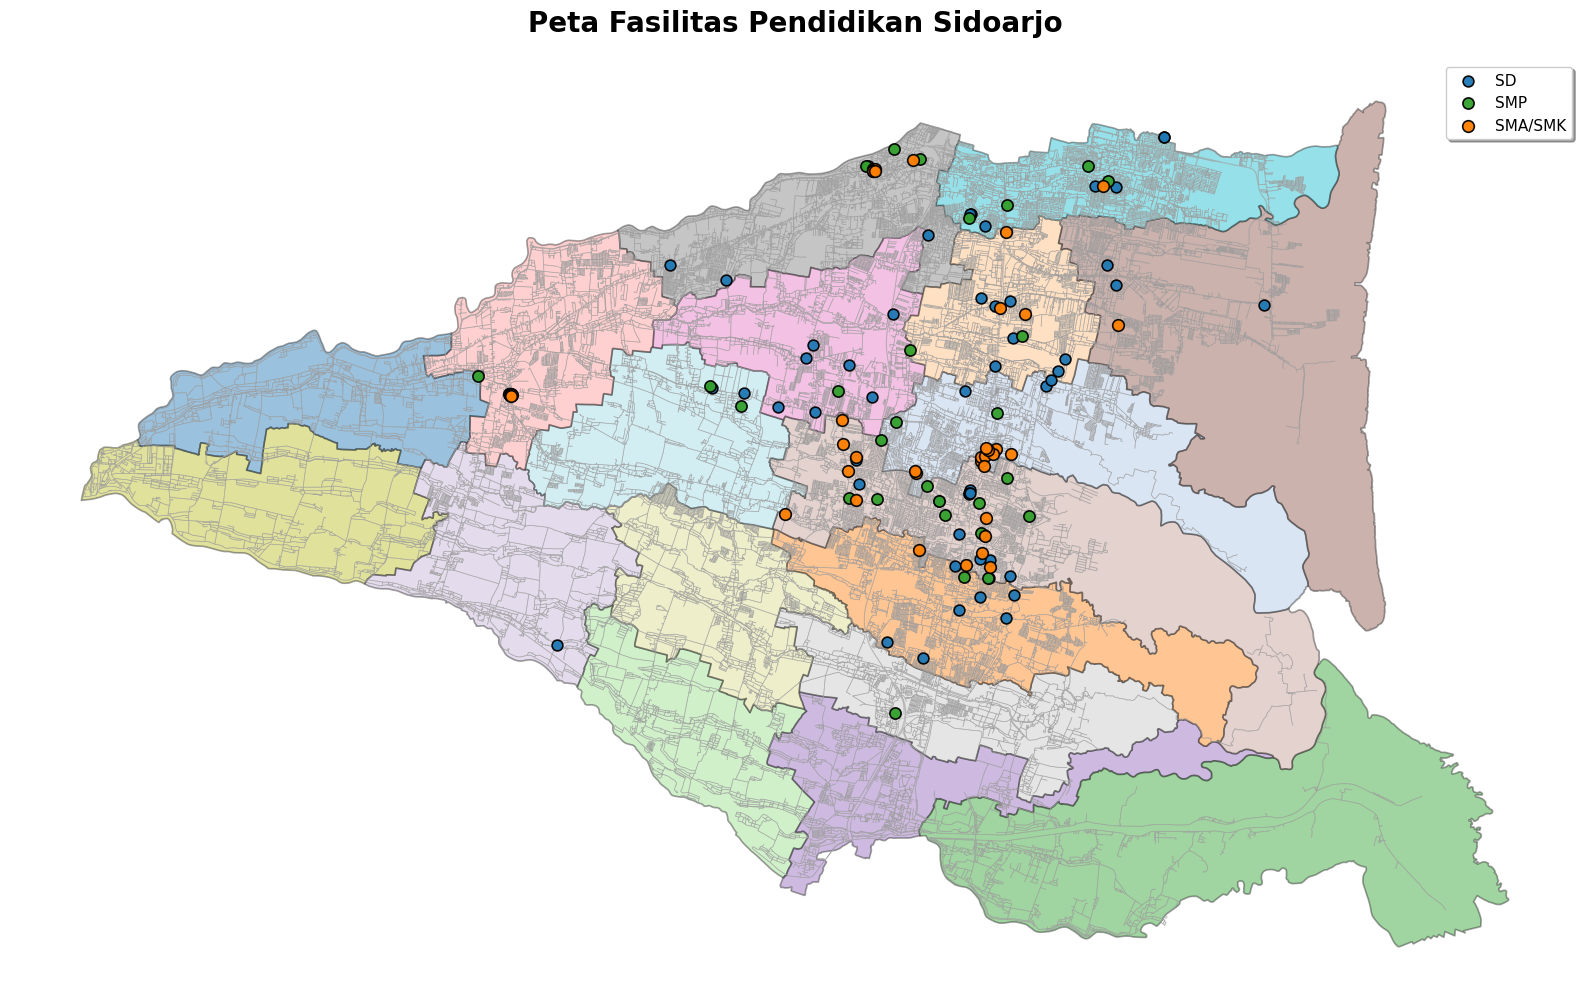

In [15]:
fig, ax = plt.subplots(figsize=(16, 13))

# Base: Kecamatan (lebih kontras tapi tetap lembut)
kecamatan.plot(
    ax=ax,
    column="nm_kecamatan",
    cmap="tab20",
    edgecolor="#2b2b2b",
    linewidth=1.2,
    alpha=0.45,
    zorder=0,
    legend=False
)

# Jalan (dibuat lebih netral agar tidak mengalahkan fasilitas)
edges.plot(
    ax=ax,
    linewidth=0.5,
    color="#9e9e9e",
    alpha=0.6,
    zorder=1
)

# Fasilitas Pendidikan
SD.plot(
    ax=ax, 
    color="#1f78b4", 
    markersize=60, 
    label="SD", 
    zorder=12,
    alpha=0.95,
    edgecolor='black',
    linewidth=1.2)

SMP.plot(
    ax=ax, 
    color="#33a02c", 
    markersize=65, 
    label="SMP", 
    zorder=12,
    alpha=0.95,
    edgecolor='black',
    linewidth=1.2)

SMA_SMK.plot(
    ax=ax, 
    color="#ff7f00", 
    markersize=70, 
    label="SMA/SMK", 
    zorder=12,
    alpha=0.95,
    edgecolor='black',
    linewidth=1.2)

ax.set_title("Peta Fasilitas Pendidikan Sidoarjo", fontsize=20, fontweight="bold", pad=20)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.legend(loc="upper right", fontsize=11, frameon=True, shadow=True)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("peta_pendidikan_sidoarjo.png", dpi=300, bbox_inches='tight')
plt.show()

#### 2. Peta Fasilitas Kesehatan

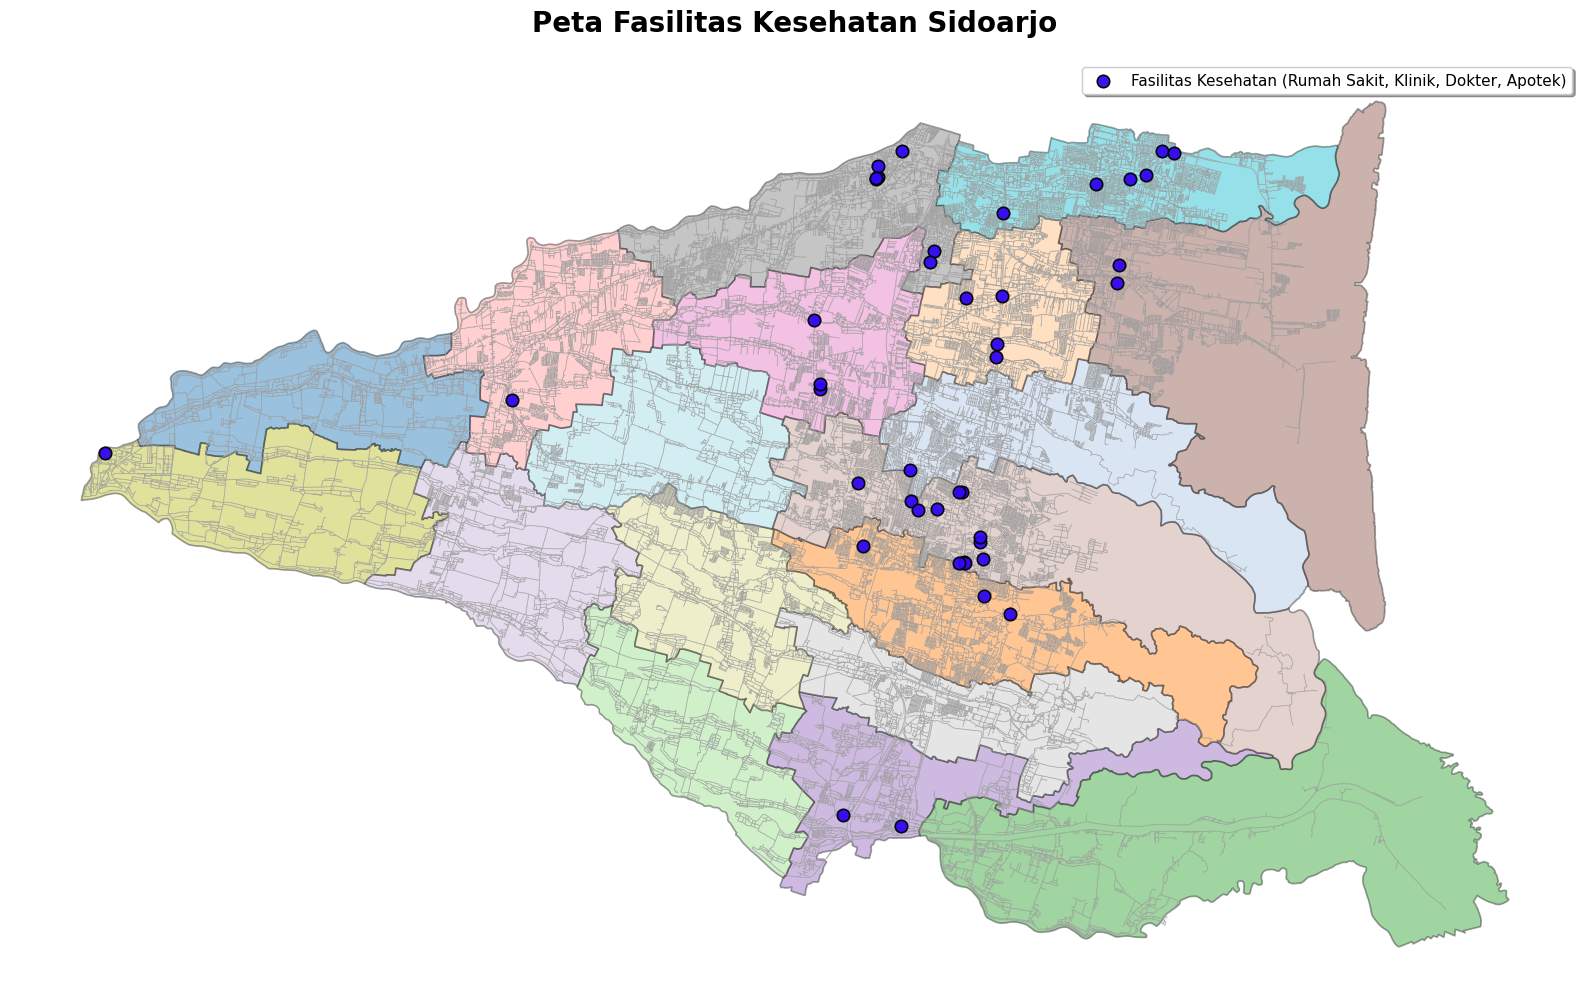

In [16]:
fig, ax = plt.subplots(figsize=(16, 13))

# Base: Kecamatan (lebih kontras tapi tetap lembut)
kecamatan.plot(
    ax=ax,
    column="nm_kecamatan",
    cmap="tab20",
    edgecolor="#2b2b2b",
    linewidth=1.2,
    alpha=0.45,
    zorder=0,
    legend=False
)

# Jalan (dibuat lebih netral agar tidak mengalahkan fasilitas)
edges.plot(
    ax=ax,
    linewidth=0.5,
    color="#9e9e9e",
    alpha=0.6,
    zorder=1
)

# Fasilitas Kesehatan
Fasilitas_Kesehatan.plot(
    ax=ax, 
    color="#3106f1", 
    markersize=80,
    label="Fasilitas Kesehatan (Rumah Sakit, Klinik, Dokter, Apotek)", 
    zorder=12,
    alpha=0.95,
    edgecolor='black',
    linewidth=1.2
)

ax.set_title("Peta Fasilitas Kesehatan Sidoarjo", fontsize=20, fontweight="bold", pad=20)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.legend(loc="upper right", fontsize=11, frameon=True, shadow=True)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("peta_kesehatan_sidoarjo.png", dpi=300, bbox_inches='tight')
plt.show()

#### 3. Peta Fasilitas Komersil

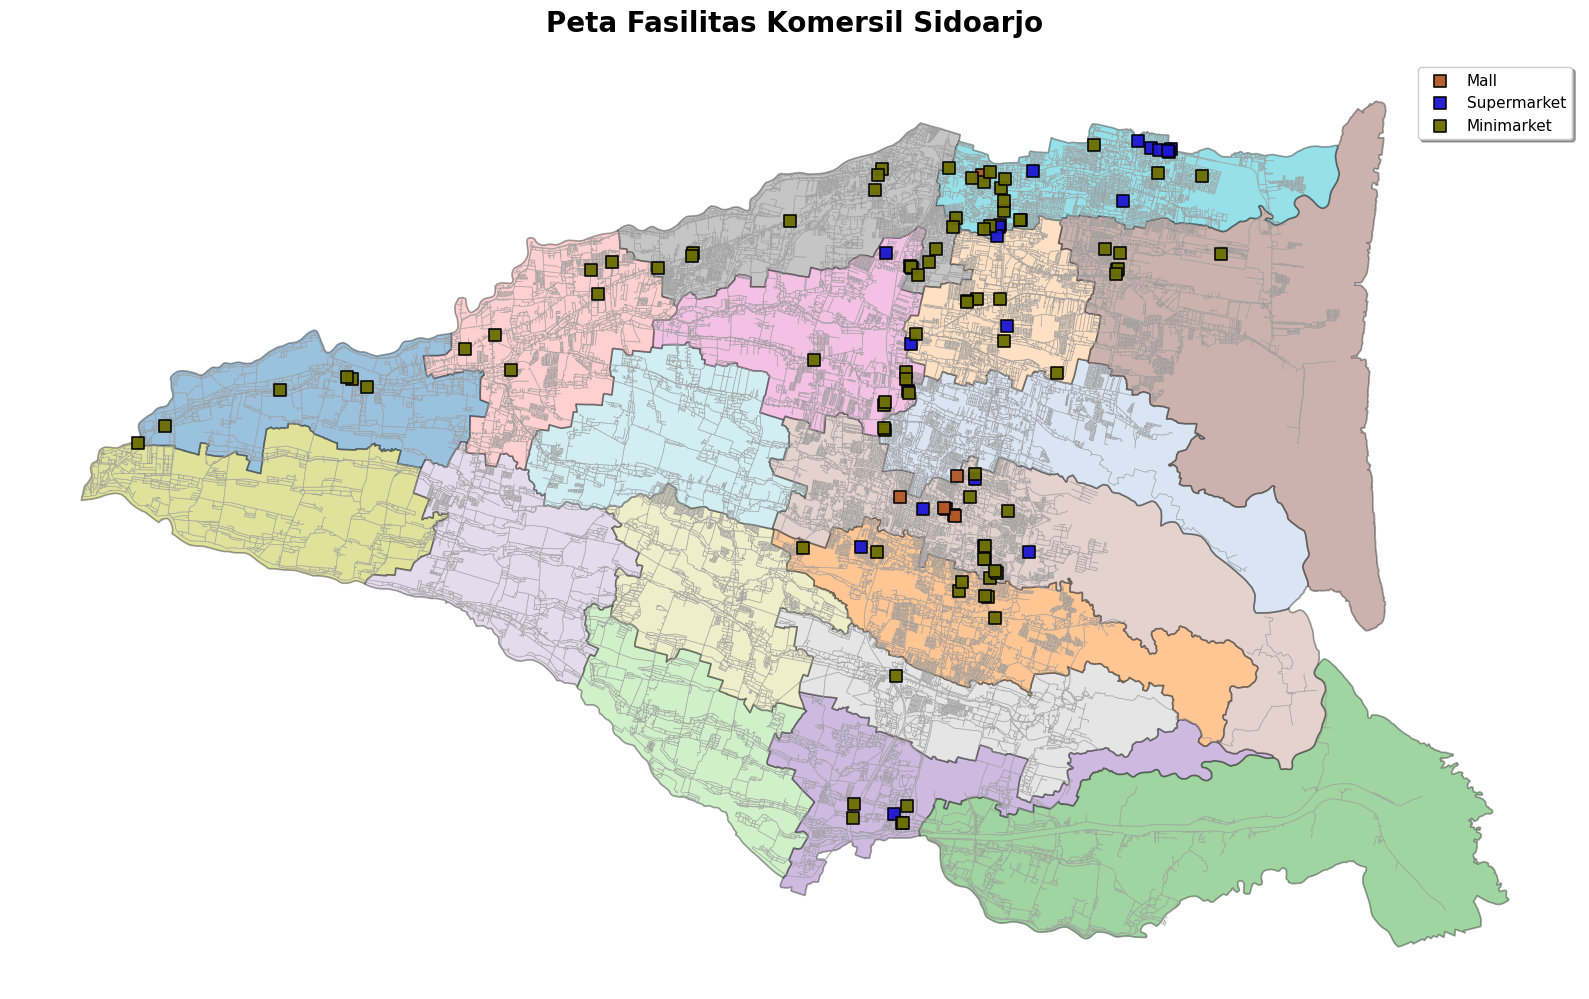

In [17]:
fig, ax = plt.subplots(figsize=(16, 13))

# Base: Kecamatan (lebih kontras tapi tetap lembut)
kecamatan.plot(
    ax=ax,
    column="nm_kecamatan",
    cmap="tab20",
    edgecolor="#2b2b2b",
    linewidth=1.2,
    alpha=0.45,
    zorder=0,
    legend=False
)

# Jalan (dibuat lebih netral agar tidak mengalahkan fasilitas)
edges.plot(
    ax=ax,
    linewidth=0.5,
    color="#9e9e9e",
    alpha=0.6,
    zorder=1
)

# Fasilitas Komersil
Mall.plot(
    ax=ax, 
    color="#b15928", 
    markersize=80, 
    marker="s", 
    label="Mall", 
    zorder=12,
    alpha=0.95,
    edgecolor='black',
    linewidth=1.2
)
Supermarket.plot(
    ax=ax, 
    color="#1c16d1", 
    markersize=80, 
    marker="s", 
    label="Supermarket", 
    zorder=12,
    alpha=0.95,
    edgecolor='black',
    linewidth=1.2
)
Minimarket.plot(
    ax=ax, 
    color="#6c6e00", 
    markersize=80, 
    marker="s", 
    label="Minimarket", 
    zorder=12,
    alpha=0.95,
    edgecolor='black',
    linewidth=1.2
)

ax.set_title("Peta Fasilitas Komersil Sidoarjo", fontsize=20, fontweight="bold", pad=20)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.legend(loc="upper right", fontsize=11, frameon=True, shadow=True)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("peta_komersil_sidoarjo.png", dpi=300, bbox_inches='tight')
plt.show()

#### 4. Peta Fasilitas Transportasi

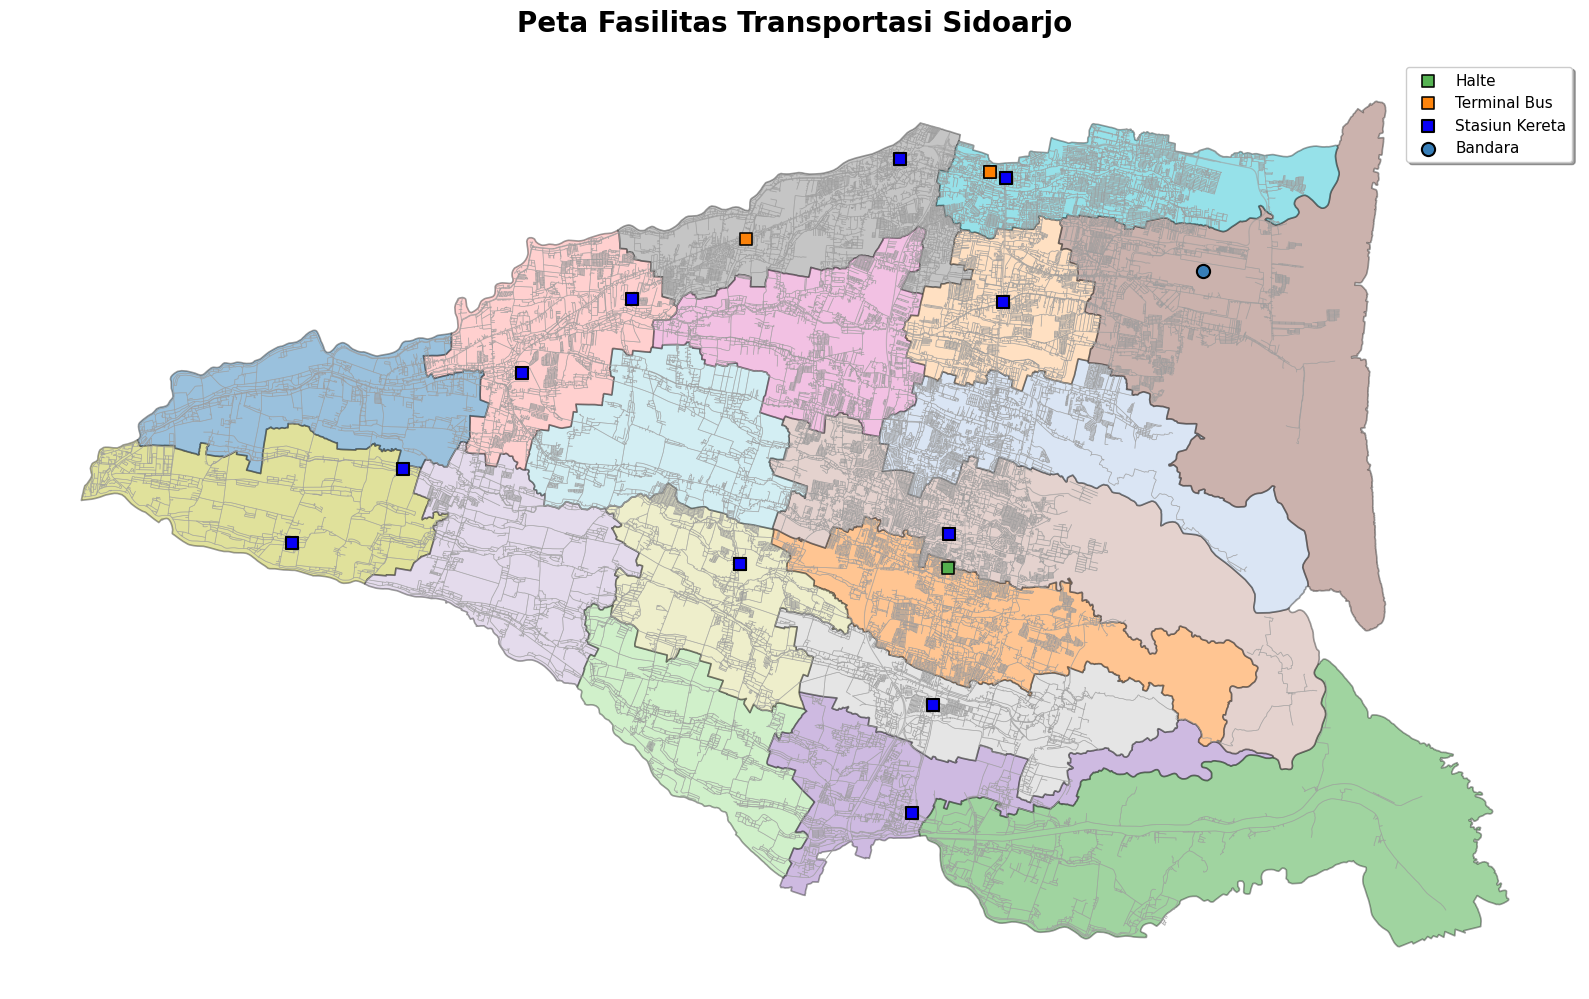

In [21]:
fig, ax = plt.subplots(figsize=(16, 13))

# Base: Kecamatan (lebih kontras tapi tetap lembut)
kecamatan.plot(
    ax=ax,
    column="nm_kecamatan",
    cmap="tab20",
    edgecolor="#2b2b2b",
    linewidth=1.2,
    alpha=0.45,
    zorder=0,
    legend=False
)

# Jalan (dibuat lebih netral agar tidak mengalahkan fasilitas)
edges.plot(
    ax=ax,
    linewidth=0.5,
    color="#9e9e9e",
    alpha=0.6,
    zorder=1
)

# Halte - paling banyak, jadi di layer paling bawah dari transportasi
Halte.plot(
    ax=ax, 
    color="#4daf4a",      # HIJAU TERANG
    markersize=80, 
    marker="s", 
    label="Halte", 
    zorder=12,
    alpha=0.95,
    edgecolor='black',
    linewidth=1.2
)

# Terminal Bus
Terminal.plot(
    ax=ax, 
    color="#ff7f00",      # ORANYE TERANG
    markersize=80, 
    marker="s", 
    label="Terminal Bus", 
    zorder=12,
    alpha=0.95,
    edgecolor='black',
    linewidth=1.2
)

# Stasiun Kereta - HARUS TERLIHAT JELAS
Stasiun.plot(
    ax=ax, 
    color="#0800f7",      # MERAH TERANG
    markersize=80,
    marker="s",           # Bintang agar lebih mencolok
    label="Stasiun Kereta", 
    zorder=15,            # Zorder tertinggi agar di atas semua
    alpha=1.0,            # Full opacity
    edgecolor='black',
    linewidth=1.5
)

# Bandara - paling penting
Bandara.plot(
    ax=ax, 
    color="#377eb8",      # BIRU TERANG
    markersize=90, 
    marker="o", 
    label="Bandara", 
    zorder=20,            # Paling atas
    alpha=1.0,
    edgecolor='black',
    linewidth=1.5
)

ax.set_title("Peta Fasilitas Transportasi Sidoarjo", fontsize=20, fontweight="bold", pad=20)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.legend(loc="upper right", fontsize=11, frameon=True, shadow=True)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("peta_transportasi_sidoarjo.png", dpi=300, bbox_inches='tight')
plt.show()

#### 5. Peta Aksesibilitas (Exit Tol)

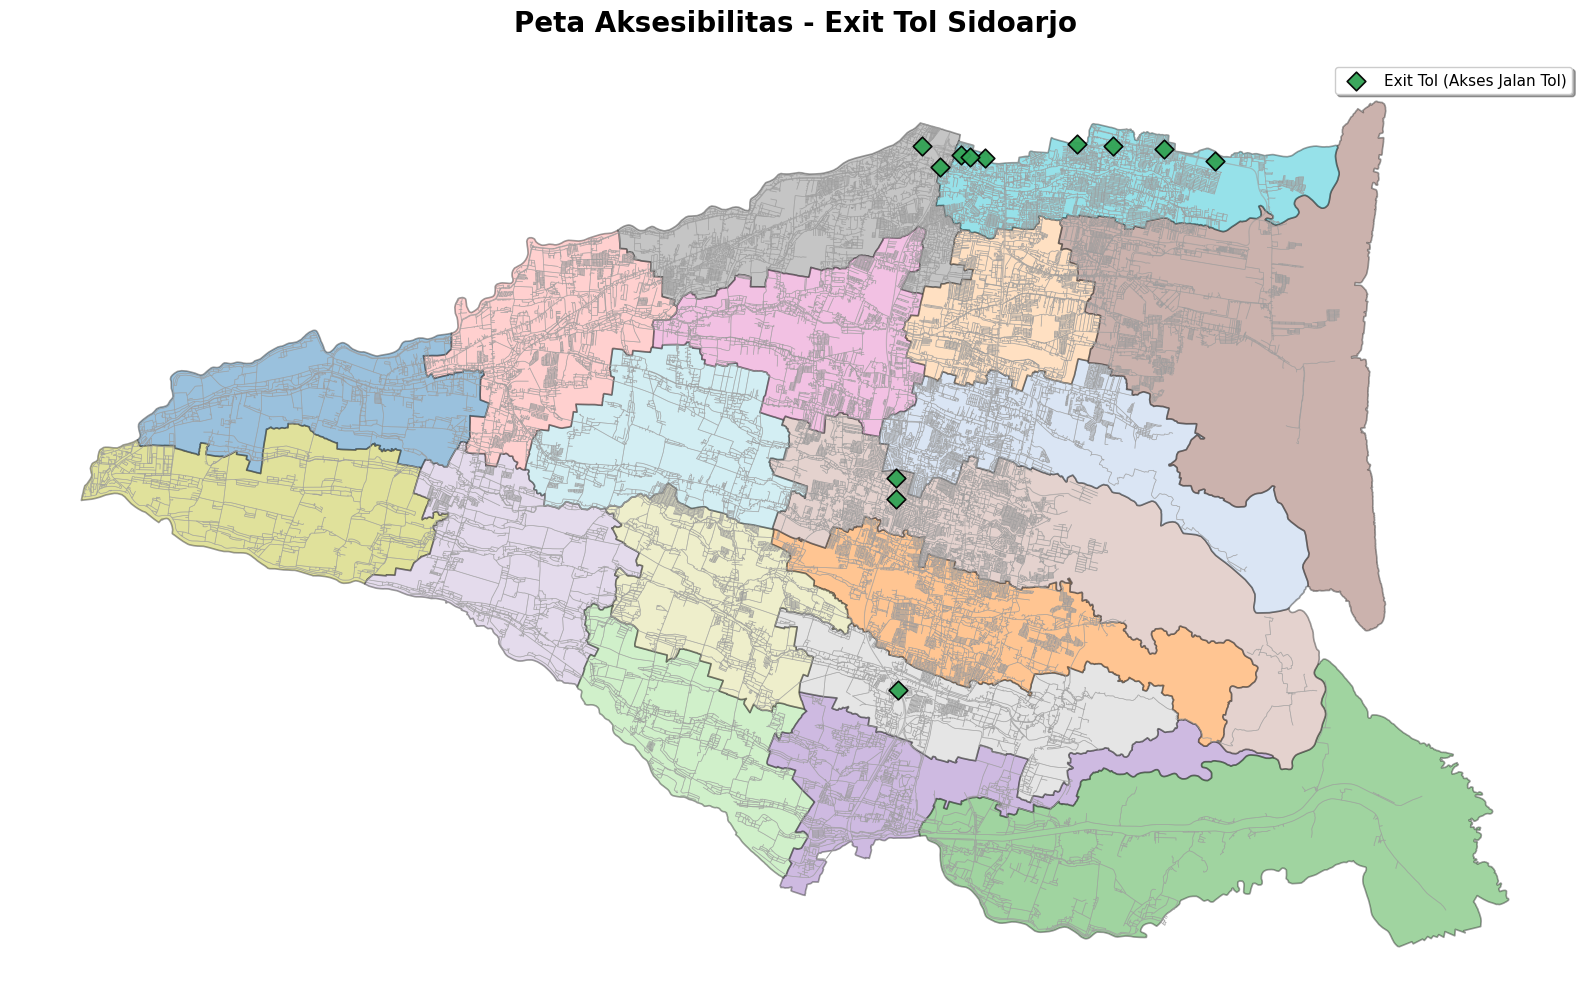

In [19]:
fig, ax = plt.subplots(figsize=(16, 13))

# Base: Kecamatan (lebih kontras tapi tetap lembut)
kecamatan.plot(
    ax=ax,
    column="nm_kecamatan",
    cmap="tab20",
    edgecolor="#2b2b2b",
    linewidth=1.2,
    alpha=0.45,
    zorder=0,
    legend=False
)

# Jalan (dibuat lebih netral agar tidak mengalahkan fasilitas)
edges.plot(
    ax=ax,
    linewidth=0.5,
    color="#9e9e9e",
    alpha=0.6,
    zorder=1
)

# Aksesibilitas - Exit Tol
Entry_Exit_Tol.plot(
    ax=ax, 
    color="#31a354", 
    markersize=90,
    marker="D", 
    label="Exit Tol (Akses Jalan Tol)", 
    zorder=12,
    alpha=0.95,
    edgecolor='black',
    linewidth=1.2
)

ax.set_title("Peta Aksesibilitas - Exit Tol Sidoarjo", fontsize=20, fontweight="bold", pad=20)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.legend(loc="upper right", fontsize=11, frameon=True, shadow=True)
ax.set_axis_off()

plt.tight_layout()
plt.savefig("peta_aksesibilitas_sidoarjo.png", dpi=300, bbox_inches='tight')
plt.show()

## Statistik Deskriptif

In [22]:
# Data properti
df_properti = pd.read_csv(
    "/mnt/extended-home/ismaprasetiyadi/skripsi/data/data_properti_sidoarjo_with_road_score.csv"
)

# Data rumah + jarak fasilitas
df_jarak = pd.read_csv(
    "/mnt/extended-home/ismaprasetiyadi/skripsi/data/data_rumah_dengan_jarak_fasilitas.csv"
)

In [24]:
print(df_properti.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Harga_Asli           1241 non-null   int64  
 1   kecamatan            1241 non-null   object 
 2   bedroom              1241 non-null   int64  
 3   bathrooms            1241 non-null   int64  
 4   jumlah_guest_toilet  1241 non-null   int64  
 5   list_facilities      1241 non-null   object 
 6   list_buildings       1241 non-null   object 
 7   lantai               1241 non-null   int64  
 8   area_digunakan       1241 non-null   int64  
 9   luas_tanah           1241 non-null   int64  
 10  latitude             1241 non-null   float64
 11  longitude            1241 non-null   float64
 12  osm_road_type        1241 non-null   object 
 13  road_score           1241 non-null   int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 135.9+ KB
None


In [26]:
stat_properti = df_properti.describe().T
stat_properti

,count,mean,std,min,25%,50%,75%,max
Harga_Asli,1241.0,9.942731e+08,1.689382e+09,5.000000,4.500000e+08,6.500000e+08,1.050000e+09,3.000000e+10
bedroom,1241.0,2.767123e+00,1.680461e+00,0.000000,2.000000e+00,2.000000e+00,3.000000e+00,2.300000e+01
bathrooms,1241.0,1.668815e+00,1.340704e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,2.300000e+01
jumlah_guest_toilet,1241.0,7.091056e-01,9.646941e-01,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+01
lantai,1241.0,1.750201e+00,5.648477e+00,1.000000,1.000000e+00,1.000000e+00,2.000000e+00,1.100000e+02
area_digunakan,1241.0,1.004561e+02,8.876481e+01,10.000000,4.000000e+01,7.200000e+01,1.200000e+02,8.000000e+02
luas_tanah,1241.0,1.131813e+02,7.269868e+01,10.000000,7.200000e+01,9.000000e+01,1.260000e+02,9.180000e+02
latitude,1241.0,-7.411858e+00,4.921577e-02,-7.572655,-7.448894e+00,-7.403915e+00,-7.368257e+00,-7.339927e+00
longitude,1241.0,1.127013e+02,6.168432e-02,112.478319,1.126739e+02,1.127066e+02,1.127470e+02,1.128165e+02
road_score,1241.0,3.210314e+00,7.599384e-01,1.000000,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


In [25]:
print(df_jarak.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Harga_Asli                1241 non-null   int64  
 1   kecamatan                 1241 non-null   object 
 2   bedroom                   1241 non-null   int64  
 3   bathrooms                 1241 non-null   int64  
 4   jumlah_guest_toilet       1241 non-null   int64  
 5   list_facilities           1241 non-null   object 
 6   list_buildings            1241 non-null   object 
 7   lantai                    1241 non-null   int64  
 8   area_digunakan            1241 non-null   int64  
 9   luas_tanah                1241 non-null   int64  
 10  latitude                  1241 non-null   float64
 11  longitude                 1241 non-null   float64
 12  dist_SD                   1239 non-null   float64
 13  dist_SMP                  1239 non-null   float64
 14  dist_SMA

In [27]:
stat_jarak = df_jarak.describe().T
stat_jarak

,count,mean,std,min,25%,50%,75%,max
Harga_Asli,1241.0,9.942731e+08,1.689382e+09,5.000000,4.500000e+08,6.500000e+08,1.050000e+09,3.000000e+10
bedroom,1241.0,2.767123e+00,1.680461e+00,0.000000,2.000000e+00,2.000000e+00,3.000000e+00,2.300000e+01
bathrooms,1241.0,1.668815e+00,1.340704e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,2.300000e+01
jumlah_guest_toilet,1241.0,7.091056e-01,9.646941e-01,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+01
lantai,1241.0,1.750201e+00,5.648477e+00,1.000000,1.000000e+00,1.000000e+00,2.000000e+00,1.100000e+02
area_digunakan,1241.0,1.004561e+02,8.876481e+01,10.000000,4.000000e+01,7.200000e+01,1.200000e+02,8.000000e+02
luas_tanah,1241.0,1.131813e+02,7.269868e+01,10.000000,7.200000e+01,9.000000e+01,1.260000e+02,9.180000e+02
latitude,1241.0,-7.411858e+00,4.921577e-02,-7.572655,-7.448894e+00,-7.403915e+00,-7.368257e+00,-7.339927e+00
longitude,1241.0,1.127013e+02,6.168432e-02,112.478319,1.126739e+02,1.127066e+02,1.127470e+02,1.128165e+02
dist_SD,1239.0,2.996891e+00,3.011408e+00,0.000000,1.167869e+00,1.956260e+00,3.788485e+00,2.079917e+01


## Distribusi Data Kontinu

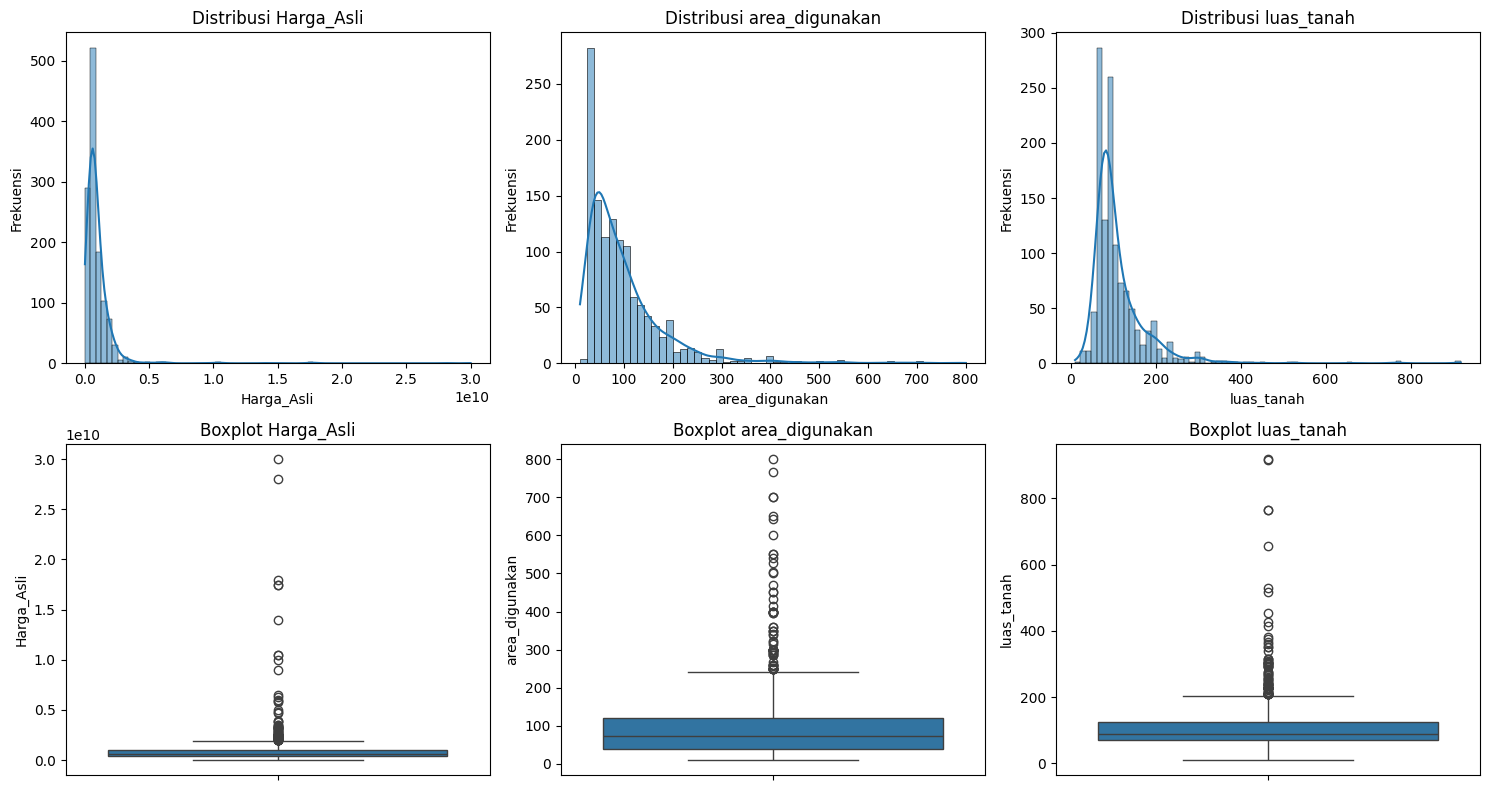

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variabel yang dianalisis
columns_to_plot = ['Harga_Asli', 'area_digunakan', 'luas_tanah']

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(columns_to_plot),
    figsize=(5 * len(columns_to_plot), 8)
)

for i, col in enumerate(columns_to_plot):
    sns.histplot(
        data=df_properti,
        x=col,
        kde=True,
        ax=axes[0, i]
    )
    axes[0, i].set_title(f'Distribusi {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frekuensi')
    sns.boxplot(
        y=df_properti[col],
        ax=axes[1, i]
    )
    axes[1, i].set_title(f'Boxplot {col}')
    axes[1, i].set_ylabel(col)
    axes[1, i].set_xlabel('')
plt.tight_layout()
plt.show()

# Map Contoh Perhitungan Jarak

Graph berarah: True
Jarak jaringan jalan: 3.48 km
Kecamatan rumah: Sidoarjo
Kecamatan tujuan: Buduran


/tmp/ipykernel_3083156/1026075082.py:195: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right', fontsize=10, frameon=True, shadow=True)


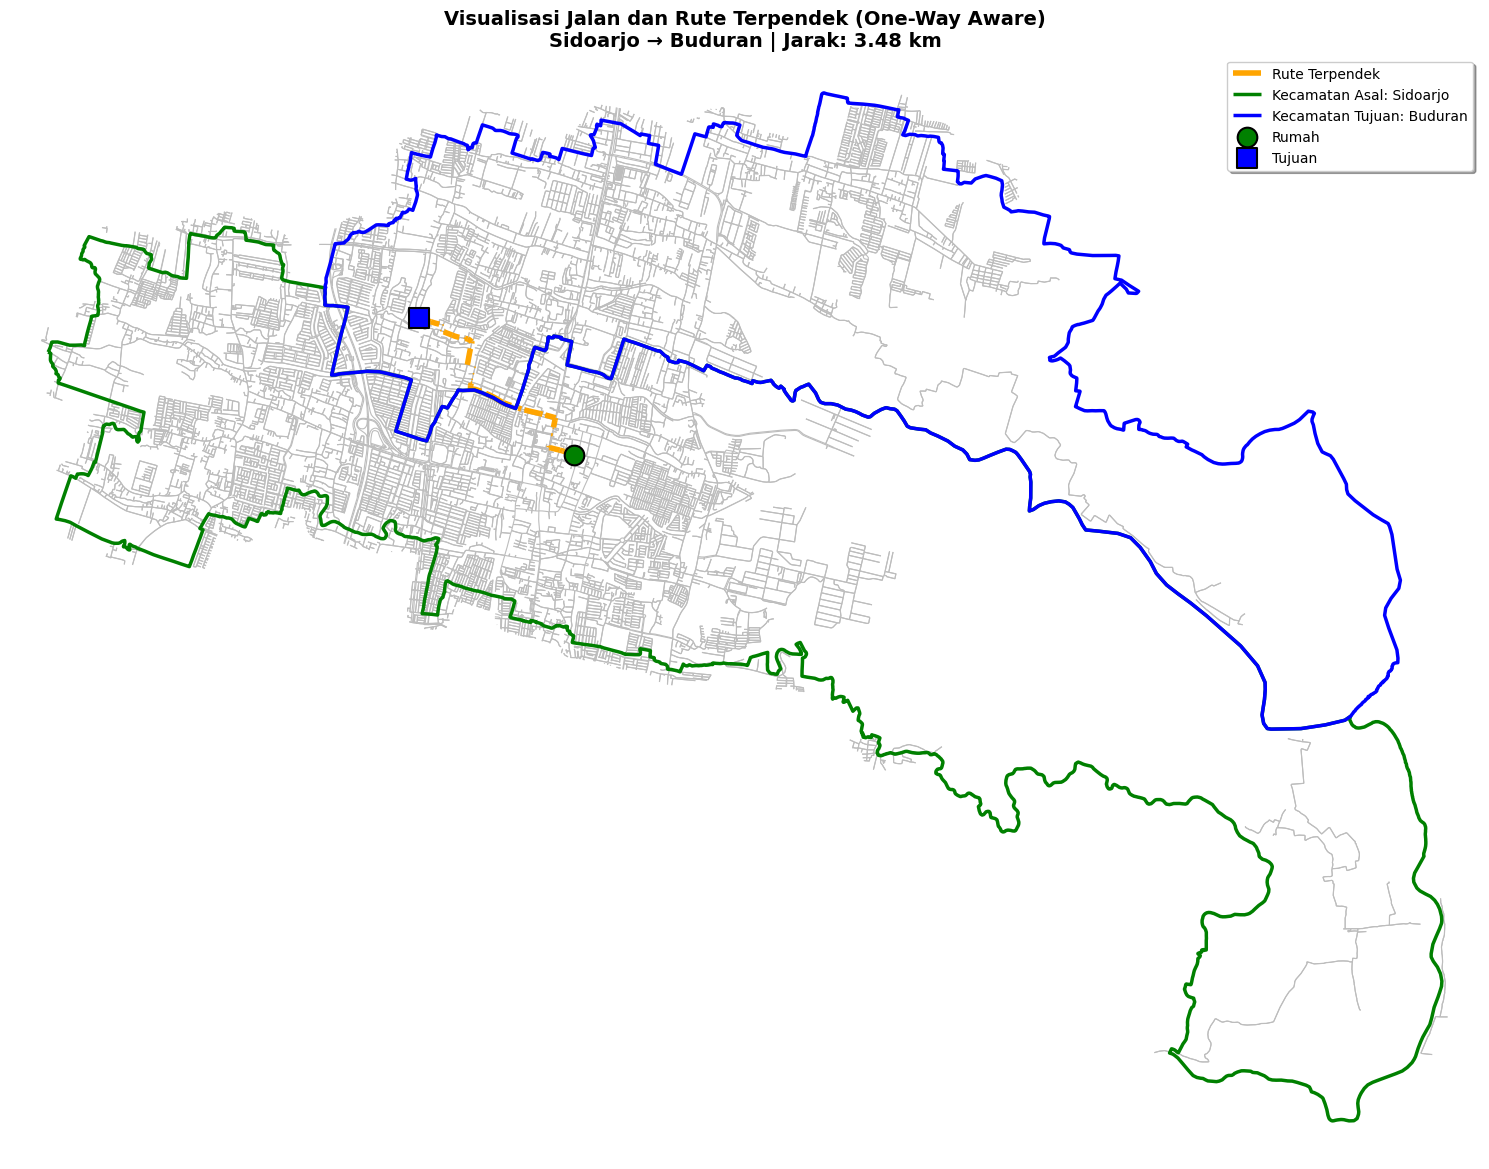

In [ ]:
import os
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point


ox.settings.use_cache = True
ox.settings.log_console = True

graph_filename = "/mnt/extended-home/ismaprasetiyadi/skripsi/data/sidoarjo_drive.graphml"

if os.path.exists(graph_filename):
    G = ox.load_graphml(graph_filename)
else:
    G = ox.graph_from_place(
        "Sidoarjo, East Java, Indonesia",
        network_type="drive"
    )
    ox.save_graphml(G, graph_filename)

print("Graph berarah:", nx.is_directed(G))

# 3. KOORDINAT (LAT, LON)
origin_point = (-7.447787128656576, 112.72162349814812)
destination_point = (-7.431854102535152, 112.70336276295606)

# 4. NODE TERDEKAT
orig_node = ox.distance.nearest_nodes(G, origin_point[1], origin_point[0])
dest_node = ox.distance.nearest_nodes(G, destination_point[1], destination_point[0])

# 5. RUTE TERPENDEK (ONE-WAY)
route = nx.shortest_path(G, orig_node, dest_node, weight="length")
route_length = nx.path_weight(G, route, weight="length")
print(f"Jarak jaringan jalan: {route_length/1000:.2f} km")

# 6. LOAD BATAS KECAMATAN
kecamatan = gpd.read_file(
    "/mnt/extended-home/ismaprasetiyadi/skripsi/data/35.15_kecamatan.geojson"
)

if kecamatan.crs is None:
    kecamatan = kecamatan.set_crs(epsg=4326)

kecamatan = kecamatan.to_crs(epsg=3857)

nama_kolom = None
for col in kecamatan.columns:
    if col.lower() in ["nm_kecamatan"]:
        nama_kolom = col
        break

if nama_kolom is None:
    raise ValueError("Kolom nama kecamatan tidak ditemukan")

# 8. TITIK RUMAH & TUJUAN (CRS METER)
rumah_gdf = gpd.GeoDataFrame(
    geometry=[Point(origin_point[1], origin_point[0])],
    crs="EPSG:4326"
).to_crs(epsg=3857)

tujuan_gdf = gpd.GeoDataFrame(
    geometry=[Point(destination_point[1], destination_point[0])],
    crs="EPSG:4326"
).to_crs(epsg=3857)


# 9. SPATIAL JOIN - KECAMATAN RUMAH DAN TUJUAN
kec_rumah = gpd.sjoin(
    kecamatan,
    rumah_gdf,
    how="inner",
    predicate="intersects"
)

kec_tujuan = gpd.sjoin(
    kecamatan,
    tujuan_gdf,
    how="inner",
    predicate="intersects"
)

if kec_rumah.empty:
    raise ValueError("Titik rumah tidak masuk kecamatan manapun")

if kec_tujuan.empty:
    raise ValueError("Titik tujuan tidak masuk kecamatan manapun")

nama_kec_rumah = kec_rumah.iloc[0][nama_kolom]
nama_kec_tujuan = kec_tujuan.iloc[0][nama_kolom]
print("Kecamatan rumah:", nama_kec_rumah)
print("Kecamatan tujuan:", nama_kec_tujuan)

# 10. GRAPH → GEODATAFRAME
nodes, edges = ox.graph_to_gdfs(G)
edges = edges.to_crs(epsg=3857)

# 11. RUTE → GEODATAFRAME (MANUAL)
# Buat list edge dari rute
route_edges_list = []
for i in range(len(route) - 1):
    u = route[i]
    v = route[i + 1]
    # Ambil edge data (bisa ada multiple edges, ambil yang terpendek)
    edge_data = G.get_edge_data(u, v)
    if edge_data:
        # Jika ada multiple edges, ambil yang pertama (key 0)
        key = 0 if isinstance(edge_data, dict) and 0 in edge_data else list(edge_data.keys())[0] if isinstance(edge_data, dict) else 0
        edge = edge_data[key] if isinstance(edge_data, dict) else edge_data
        route_edges_list.append({
            'u': u,
            'v': v,
            'geometry': edge.get('geometry', Point(G.nodes[u]['x'], G.nodes[u]['y']).buffer(0.0001))
        })

# Buat GeoDataFrame dari route edges
route_edges = gpd.GeoDataFrame(route_edges_list, crs="EPSG:4326").to_crs(epsg=3857)

# 12. CLIP JALAN (BUFFER AMAN - KEDUA KECAMATAN)
# Gabungkan kedua kecamatan untuk clip jalan
kec_gabungan = gpd.GeoDataFrame(
    pd.concat([kec_rumah, kec_tujuan], ignore_index=True),
    crs=kec_rumah.crs
)
kec_buffer = kec_gabungan.geometry.buffer(200)
edges_clip = gpd.clip(edges, kec_buffer)

# 13. VISUALISASI
fig, ax = plt.subplots(figsize=(15, 12))

# Jalan di kedua kecamatan
edges_clip.plot(ax=ax, color="#bdbdbd", linewidth=0.8, zorder=1)

# Rute terpendek
route_edges.plot(ax=ax, color="orange", linewidth=4, zorder=3, label="Rute Terpendek")

# Boundary kecamatan rumah (hijau)
kec_rumah.boundary.plot(
    ax=ax, 
    edgecolor="green", 
    linewidth=2.5, 
    zorder=4, 
    label=f"Kecamatan Asal: {nama_kec_rumah}"
)

# Boundary kecamatan tujuan (biru)
kec_tujuan.boundary.plot(
    ax=ax, 
    edgecolor="blue", 
    linewidth=2.5, 
    zorder=4, 
    label=f"Kecamatan Tujuan: {nama_kec_tujuan}"
)

# Titik rumah dan tujuan
rumah_gdf.plot(ax=ax, color="green", markersize=200, zorder=5, marker='o', edgecolor='black', linewidth=1.5, label="Rumah")
tujuan_gdf.plot(ax=ax, color="blue", markersize=200, zorder=5, marker='s', edgecolor='black', linewidth=1.5, label="Tujuan")

# 14. ZOOM - KEDUA KECAMATAN
minx, miny, maxx, maxy = kec_gabungan.total_bounds
ax.set_xlim(minx - 500, maxx + 500)
ax.set_ylim(miny - 500, maxy + 500)

ax.set_axis_off()
ax.legend(loc='upper right', fontsize=10, frameon=True, shadow=True)
plt.title(
    f"Visualisasi Jalan dan Rute Terpendek (One-Way Aware)\n"
    f"{nama_kec_rumah} → {nama_kec_tujuan} | Jarak: {route_length/1000:.2f} km",
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()
plt.show()
